# Model-based embeddings: a distance for records that don't have one

How to visualize data that has no natural metric - records mixing numbers, categories, counts, sets, sequences, rankings, and missing fields - by letting a fitted generative model supply the distance. You'll see why a model's posterior over mixture components is the right fingerprint, measure the separation quantitatively (not just by eye), and understand how the affinity choice can make or break the map.

t-SNE and UMAP need a distance between points. That's easy for vectors of numbers - but what is the distance between two customers, when each is a tangle of a number (age), a category (region), a count (purchases), a set (interests), a sequence (browse session), a ranking (favourite brands), and a sometimes-missing field? There is no natural metric across those types, so you can't drop them into ordinary t-SNE.

`htsne`/`humap` solve this by letting a generative model supply the distance: fit a mixture to the heterogeneous records, and use each record's posterior over the mixture components as its fingerprint - two records are close when the model explains them the same way. The map then reflects what the model thinks each record is, fusing every field type at once.

This notebook tells that story on richly heterogeneous customer profiles, and then unpacks why the posterior-as-affinity idea works (and how the naive version fails). The calling syntax is in embedding_with_htsne.


## Embeddings as neighbor-preserving maps

A low-dimensional embedding seeks points $y_i\in\mathbb R^2$ whose neighbor relationships match those of
the high-dimensional (or model-based) data. The model-based affinity here defines high-dimensional
similarities from posteriors (the affinity discussion in this notebook); t-SNE and UMAP then place the
$y_i$ to reproduce those similarities.

Definition (t-SNE objective). Convert high-dimensional distances to a joint neighbor distribution $P$
(Gaussian affinities, symmetrized) and low-dimensional ones to a distribution $Q$ using a heavy-tailed
Student-t kernel, then minimize $\mathrm{KL}(P\,\|\,Q)$ over the $y_i$. The KL is small when points that
are neighbors in $P$ are neighbors in $Q$.

Theorem (the crowding problem and the heavy-tailed fix). In low dimensions there is far less room than in
high dimensions, so moderate-distance points cannot all be placed at their true distances; a Gaussian
low-dimensional kernel forces them too close and crushes the layout. The Student-t kernel, with its heavy
tail, lets moderately dissimilar points sit far apart at low cost, which resolves the crowding and is the
key design choice that makes t-SNE work.

## What an embedding does and does not preserve

Because the objective rewards matching the neighbor distribution, t-SNE and UMAP preserve local structure:
nearby points stay nearby. They do not preserve global geometry.

Theorem (non-convex, local optima). The t-SNE objective is non-convex in the point positions, so
optimization (gradient descent with momentum) finds a local optimum that depends on the random
initialization and seed. There is no canonical global solution, and runs differ.

Counterexamples (do not over-read the picture). Three things in a t-SNE or UMAP plot are not meaningful:
the sizes of clusters (the heavy-tailed kernel distorts densities), the distances between separated
clusters (only local neighborhoods are fit), and the absolute orientation (rotations and reflections are
free). The stability check in this notebook quantifies exactly how much the local neighborhoods, the part
that is meaningful, are reproduced across seeds, and warns against interpreting the rest.

In [1]:
import io
import numpy as np
import matplotlib.pyplot as plt
from mixle.stats import (GaussianDistribution, CategoricalDistribution, PoissonDistribution,
                        BernoulliSetDistribution, OptionalDistribution, CompositeDistribution,
                        MixtureDistribution, SequenceDistribution, IntegerCategoricalDistribution,
                        SpearmanRankingDistribution)
from mixle.utils.hvis import htsne, humap

TAGS = ['sports', 'games', 'books', 'art', 'tech', 'travel']
NAMES = ['young gamers', 'big spenders', 'EU arts crowd', 'older travellers']

def region(**w):                                   # a categorical over regions (normalized)
    d = {r: w.get(r, 0.1) for r in ['US', 'EU', 'APAC']}; s = sum(d.values())
    return {r: v / s for r, v in d.items()}

def segment(age, reg, purch, tags, premium, session, brand_rank):
    # each customer record is a Composite of SEVEN heterogeneous fields
    return CompositeDistribution((
        GaussianDistribution(age, 6.0),                                            # age            (continuous)
        CategoricalDistribution(reg),                                              # region         (category)
        PoissonDistribution(purch),                                                # # purchases    (count)
        BernoulliSetDistribution({t: tags.get(t, 0.1) for t in TAGS}),             # interests      (SET)
        OptionalDistribution(GaussianDistribution(premium, 1.0), p=0.5),           # premium spend  (maybe-missing)
        SequenceDistribution(IntegerCategoricalDistribution(0, session),
                             len_dist=PoissonDistribution(4.0)),                    # browse session (SEQUENCE)
        SpearmanRankingDistribution(brand_rank)))                                  # brand ranking  (RANKING)

segments = [
    segment(30, region(US=.5, EU=.4),  5, {'sports': .8, 'games': .8}, 2.0, [.6, .2, .2], [.5, .3, .2, .1]),
    segment(35, region(US=.45, EU=.45), 25, {'tech': .7},              10.0, [.2, .6, .2], [.1, .2, .3, .5]),
    segment(33, region(EU=.8),          6, {'books': .85, 'art': .85},  2.5, [.2, .2, .6], [.3, .5, .1, .2]),
    segment(50, region(US=.7),          4, {'travel': .6},              3.0, [.4, .3, .3], [.2, .1, .4, .4]),
]
truth = MixtureDistribution(segments, [0.25] * 4)

rng = np.random.RandomState(0)
data, labels = [], []
for _ in range(400):
    k = rng.choice(4)
    data.append(truth.components[k].sampler(seed=rng.randint(2**31)).sample()); labels.append(k)
labels = np.array(labels)
print('%d customer records, each a 7-field heterogeneous profile' % len(data))

400 customer records, each a 7-field heterogeneous profile


## One record, seven kinds of field

Here is a single customer. Ask yourself: what is the Euclidean distance between this record and the next one? There isn't one - you'd have to invent a way to compare a set of interests to a ranking to a count. That invention is exactly what the generative model does for you.


In [2]:
fields = ['age', 'region', 'purchases', 'interests(set)', 'premium(opt)', 'session(seq)', 'brand_rank']
for f, v in zip(fields, data[0]):
    print('  %-16s %s' % (f, v))

  age              31.12517256044099
  region           US
  purchases        6
  interests(set)   ['sports', 'games']
  premium(opt)     2.003133587195763
  session(seq)     [np.int64(2), np.int64(0), np.int64(2)]
  brand_rank       [1, 3, 0, 2]


## No field you can plot tells the whole story

Of the seven fields, only two are plain numbers you could scatter directly: age and purchases. Plotting the customers on those two axes, the big spenders peel off (high purchases) and the older travellers peel off (high age) - but young gamers and the EU arts crowd land right on top of each other. On the numeric fields they are indistinguishable; what separates them lives in their interests, region, and browse sessions - fields you can't put on an axis.


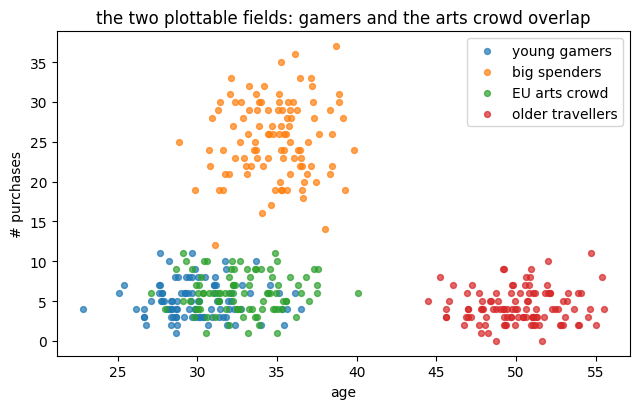

In [3]:
age = np.array([d[0] for d in data]); purch = np.array([d[2] for d in data])
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for k in range(4):
    m = labels == k
    ax.scatter(age[m], purch[m], s=18, alpha=0.7, label=NAMES[k])
ax.set_xlabel('age'); ax.set_ylabel('# purchases'); ax.legend()
ax.set_title('the two plottable fields: gamers and the arts crowd overlap')
plt.tight_layout(); plt.show()

## Let the model supply the distance

`htsne(data)` fits a mixture to the whole 7-field record and embeds each customer by its posterior over the components. Now every field - set, sequence, ranking and all - contributes, and the four segments fall cleanly apart, including the two that were inseparable on the numeric axes. The colours are the true segments; the embedding never saw them.


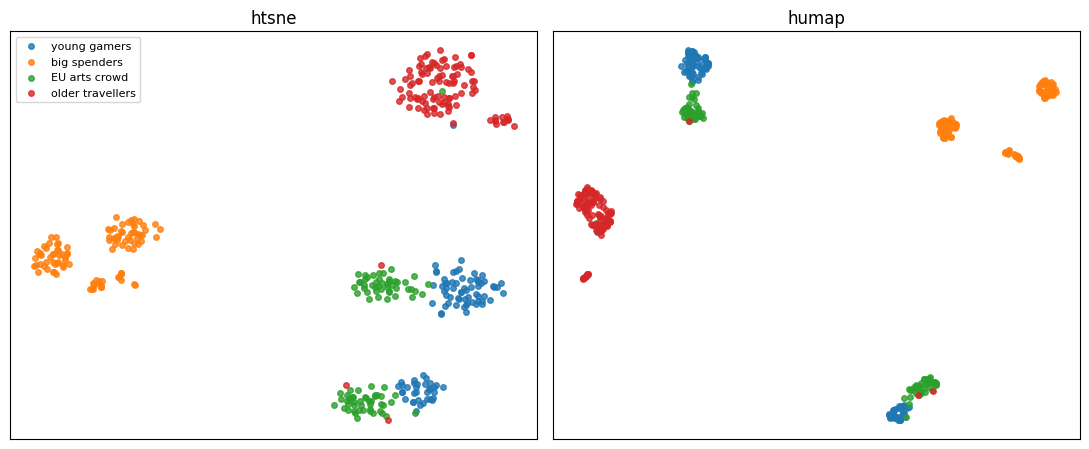

In [4]:
Y_tsne = htsne(data, seed=1, perplexity=30, affinity='auto', out=io.StringIO())
Y_umap = humap(data, seed=1, n_neighbors=20, affinity='auto', out=io.StringIO())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, Y, title in zip(axes, [Y_tsne, Y_umap], ['htsne', 'humap']):
    for k in range(4):
        m = labels == k
        ax.scatter(Y[m, 0], Y[m, 1], s=16, alpha=0.8, label=NAMES[k])
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Quantifying the separation

"The segments fall apart" should be a number, not a vibe. A standard, label-aware diagnostic for an embedding is k-nearest-neighbor label purity: for each point, what fraction of its $k$ nearest neighbors in the map share its true segment? (1.0 = perfectly clustered, $\approx$ the largest class fraction = no structure.) We compare the model-based embedding against the best you can do with the only two plottable numeric fields - the gap is the value added by the set/region/session/ranking fields that have no native metric.


In [5]:
from sklearn.neighbors import NearestNeighbors

def knn_purity(Y, lab, k=10):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)[:, 1:]
    return np.mean([(lab[idx[i]] == lab[i]).mean() for i in range(len(lab))])

numeric_only = np.column_stack([age, purch])           # the two fields you could actually scatter
print('kNN label purity (k=10):')
print('  numeric fields only : %.3f' % knn_purity(numeric_only, labels))
print('  htsne (all 7 fields): %.3f' % knn_purity(Y_tsne, labels))
print('  humap (all 7 fields): %.3f' % knn_purity(Y_umap, labels))
print('  chance (largest seg): %.3f' % (np.bincount(labels).max() / len(labels)))

kNN label purity (k=10):
  numeric fields only : 0.821
  htsne (all 7 fields): 0.968
  humap (all 7 fields): 0.965
  chance (largest seg): 0.270


## The affinity is the lever

The same fitted model can yield different maps depending on how its posteriors become affinities. The default `'auto'` (per-field, evidence-capped) is robust; `'coassign'` (probability two points share a component) gives crisp islands but can collapse genuine structure; `'bhattacharyya'` and `'fisher'` sit in between. It's worth comparing on your own data.


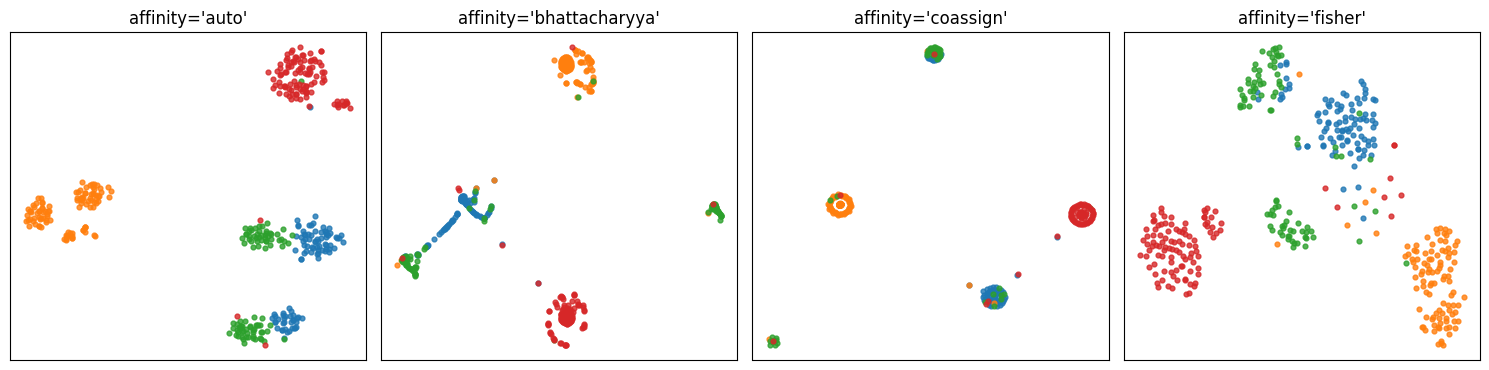

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, aff in zip(axes, ['auto', 'bhattacharyya', 'coassign', 'fisher']):
    Y = htsne(data, seed=1, perplexity=30, affinity=aff, out=io.StringIO())
    for k in range(4):
        m = labels == k
        ax.scatter(Y[m, 0], Y[m, 1], s=12, alpha=0.8)
    ax.set_title("affinity='%s'" % aff); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## The one principle - and how the naive version fails

The whole method is: embed each point by its posterior over a fitted mixture's components, and measure affinity in that posterior space. The posterior is a soft, low-dimensional summary that already fuses every field on a common (probability) scale - which is why heterogeneous types just work.

The subtlety is how you turn two posteriors into one affinity. The naive choice - co-assignment probability with a single shared mixture - ties all fields together and, when components overlap, collapses everything into a few dense blobs or rings, destroying within-cluster geometry. The default instead computes affinities per field with an evidence cap, so a single confident field can't dominate and the layout keeps its fine structure. The contrast below, on a plain 4-component Gaussian mixture, makes the failure visible.


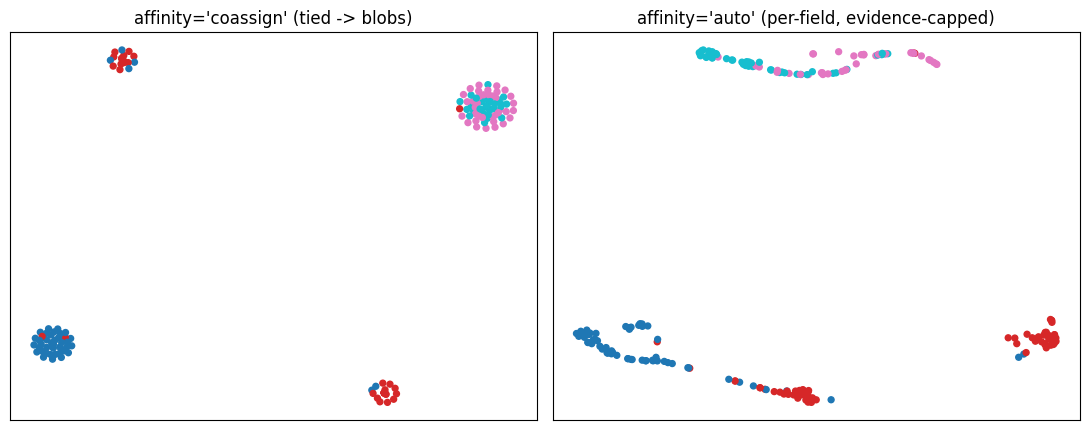

In [7]:
# a clean, fully-numeric example so the affinity effect is unmistakable
from mixle.stats import DiagonalGaussianDistribution
gmm = MixtureDistribution([DiagonalGaussianDistribution([c]*4, [0.5]*4) for c in (0, 1, 2, 3)],
                          [0.3, 0.3, 0.2, 0.2])
gdata, glab = [], []
for _ in range(200):
    k = np.random.RandomState(_).choice(4, p=gmm.w); gdata.append(gmm.components[k].sampler(seed=_).sample()); glab.append(k)
glab = np.array(glab)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, aff, title in zip(axes, ['coassign', 'auto'],
                          ["affinity='coassign' (tied -> blobs)", "affinity='auto' (per-field, evidence-capped)"]):
    Y = htsne(gdata, seed=1, perplexity=20, affinity=aff, out=io.StringIO())
    ax.scatter(Y[:, 0], Y[:, 1], c=glab, cmap='tab10', s=18); ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Takeaways

- A generative model is a distance for anything. Records mixing numbers, categories, counts, sets, sequences, rankings, and missing fields have no native metric; their posteriors over a fitted mixture do. `htsne(data)` is the whole call.
- It fuses fields you can't even plot. The two segments that overlapped on every numeric axis separated cleanly once the set/region/session fields entered through the model.
- The affinity is a real choice. `affinity='auto'` (per-field, evidence-capped) is the robust default; `coassign` is crisper but can collapse structure - compare them on your data.

For the applied version, see the malware certificate embedding; for the calling surface and `mix_model=`, see embedding_with_htsne.


## Check embedding stability before reading the layout

t-SNE/UMAP layouts are stochastic - global distances and even cluster placement vary with the random seed, so over-interpreting one run is a classic mistake (Wattenberg et al. 2016). The right check is the reproducibility of the local neighborhood: embed twice from different seeds and measure the mean $k$-NN Jaccard overlap, compared against the chance level for random neighbor sets. Overlap far above chance means the neighbor structure carries real signal even though exact neighbor lists - and the global arrangement - still shift between runs.


In [8]:
from sklearn.neighbors import NearestNeighbors
def knn_sets(Y, k=10):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)[:, 1:]
    return [set(r) for r in idx]
Ya = knn_sets(htsne(data, seed=1, perplexity=30, affinity='auto', out=io.StringIO()))
Yb = knn_sets(htsne(data, seed=7, perplexity=30, affinity='auto', out=io.StringIO()))
jac = np.mean([len(Ya[i] & Yb[i]) / len(Ya[i] | Yb[i]) for i in range(len(Ya))])
k, N = 10, len(data)
chance = (k * k / N) / (2 * k - k * k / N)            # expected Jaccard for random neighbor sets
print('mean 10-NN Jaccard overlap between two seeds = %.2f  (chance level ~ %.2f)' % (jac, chance))
print('%.0fx above chance => the local neighbor structure is real signal, not noise,' % (jac / chance))
print('but well below 1.0: exact neighbor lists and the global layout still shift run-to-run -- read groupings, not coordinates.')

mean 10-NN Jaccard overlap between two seeds = 0.27  (chance level ~ 0.01)
21x above chance => the local neighbor structure is real signal, not noise,
but well below 1.0: exact neighbor lists and the global layout still shift run-to-run -- read groupings, not coordinates.


## References

- van der Maaten, L. & Hinton, G. (2008). Visualizing data using t-SNE (https://jmlr.org/papers/v9/vandermaaten08a.html). JMLR 9, 2579-2605.
- Hinton, G. & Roweis, S. (2002). Stochastic neighbor embedding (https://papers.nips.cc/paper/2002/hash/6150ccc6069bea6b5716254057a194ef-Abstract.html). NeurIPS.
- McInnes, L., Healy, J. & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection (https://arxiv.org/abs/1802.03426). arXiv:1802.03426.
- Venna, J. & Kaski, S. (2006). Local multidimensional scaling (https://doi.org/10.1016/j.neunet.2006.05.014). Neural Networks 19(6-7), 889-899. - trustworthiness/continuity.
- Wattenberg, M., Viégas, F. & Johnson, I. (2016). How to use t-SNE effectively (https://doi.org/10.23915/distill.00002). Distill.


## Exercises and extensions

1. Quantify the embedding. Implement trustworthiness and continuity (Venna & Kaski) and the kNN-label-purity metric; compare the model-based (posterior-affinity) embedding to Euclidean t-SNE on the raw heterogeneous fields, and to a one-hot/Gower flattening. Show the model-based affinity wins where types are mixed.
2. Hyperparameter sensitivity. Sweep perplexity (t-SNE) and `n_neighbors`/`min_dist` (UMAP) and document how cluster sizes and inter-cluster distances distort (Wattenberg et al.: "cluster sizes mean nothing"); establish a robust default range via the quality metrics.
3. Reproduce the failure modes. Reproduce the degenerate-affinity rings/blobs from the notebook on a controlled Gaussian mixture, and explain via the SNE/t-SNE objective (Hinton-Roweis; van der Maaten-Hinton) why a tied co-assignment affinity collapses structure.
4. Bring your own model. Fit a richer mixture yourself and pass it as `mix_model=`; show the embedding is only as good as the generative model defining its affinities, and that improving the model improves the map (by the metrics in #1).
